# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Saffira Arentsen
* Username: sarentsen
* Student number: s6239145
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
from sympy import Symbol, integrate
import sympy
from scipy.integrate import quad
from numpy import sin, cos, exp, pi

class integrating():
    def __init__(self, f, a, b):
        self.f = f
        self.a = a
        self.b = b
        
    def trapezium(self):
        x = self.a
        f_a = eval(self.f)
        x = self.b
        f_b = eval(self.f)
        integral = (self.b-self.a)*(f_a+f_b)/2
        return integral
        
    def simpson(self):
        n = 1000
        h = (self.b - self.a) / n
        x = np.linspace(a, b, n+1)
        def func(x):
            return eval(self.f)
        y = func(x)
        integral = h/3 * (y[0] + 4*y[1::2].sum() + 2*y[2::2].sum())
        return integral
        
    def monte_carlo(self):
        N = 1000
        x = np.random.uniform(self.a,self.b, N)
        f = eval(self.f)
        integral = (self.b-self.a) * np.mean(f)
        return integral
        
    def sympy_integrate(self):
        x = Symbol('x')
        sin = sympy.sin
        cos = sympy.cos
        f = eval(self.f)
        intg = integrate(f, (x, self.a, self.b))
        return intg
        
    def scipy_quad(self):
        def func(x):
            f = eval(self.f)
            return f
        area = quad(func, self.a, self.b)
        return area
    
f = '1 + x + 2 * sin(x)'
a, b = 0.5, 3.0
ex = integrating(f, a, b)
print(f'Trapezium result: {ex.trapezium()}')
print(f'Simpson result: {ex.simpson()}')
print(f'Monte carlo result: {ex.monte_carlo()}')
print(f'Sympy result: {ex.sympy_integrate()}')
print(f'Scipy quad result: {ex.scipy_quad()}')

Trapezium result: 8.426363866660175
Simpson result: 10.613718650329215
Monte carlo result: 10.64519898557473
Sympy result: 10.6101501169816
Scipy quad result: (10.610150116981638, 1.1779632954602313e-13)


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

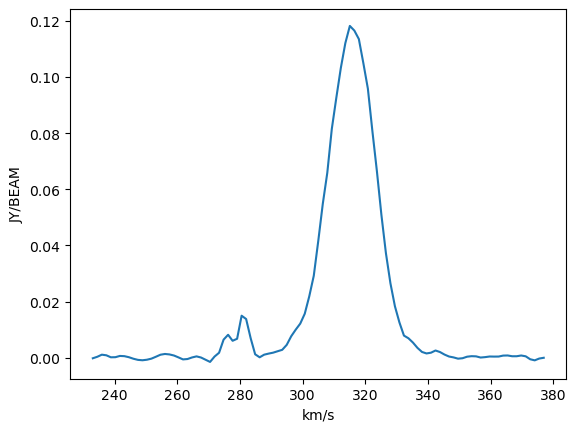

In [4]:
from astropy.io import fits
from matplotlib.pyplot import figure, show
import numpy as np

# Getting the correct data
hdu = fits.open('ngc6946.fits')
hdr = hdu[0].header
data = hdu[0].data 
profile = data[:,55,58]
v = np.linspace(233, 377, len(profile))

# Plotting
fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(v, profile)
frame.set_xlabel(hdr['CUNIT3'])
frame.set_ylabel(hdr['BUNIT'])
show()


In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
import numpy as np
def f(x, amp, mu, sigma, zero):
    return zero + amp * np.exp(-((x - mu)**2) / (2 * sigma**2))

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [8]:
# For linear models the first derivative of the model with respect to any parameters is zero or depends only on the independent variable.
# If this is not true then the problem is a non-linear model.
from sympy import symbols, diff
import sympy
x,amp,mu,sigma,zero=symbols("x,amp,mu,sigma,zero")
function_f = zero + amp * sympy.exp(-((x - mu)**2) / (2 * sigma**2))
print(diff(function_f, zero))
print(diff(function_f, sigma))
print(diff(function_f, mu))
print(diff(function_f, amp))
print('f is a non-linear model')


1
amp*(-mu + x)**2*exp(-(-mu + x)**2/(2*sigma**2))/sigma**3
-amp*(2*mu - 2*x)*exp(-(-mu + x)**2/(2*sigma**2))/(2*sigma**2)
exp(-(-mu + x)**2/(2*sigma**2))
f is a non-linear model


In [9]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [10]:
import numpy as np
from scipy.optimize import curve_fit

amp0 = (np.max(profile)-np.min(profile)) # Difference in min and max values is reasonable for the amplitude
mu0 = 318 # the centered position should be roughly where the maximum is
sigma0 = 12 # looking at the plotted profile, this is what I would estimate the width to be
zero0 = np.min(profile) # The offset is at least the minimal value of the profile
popt, pcov2 = curve_fit(f, v, profile, p0=(amp0, mu0, sigma0, zero0))


In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

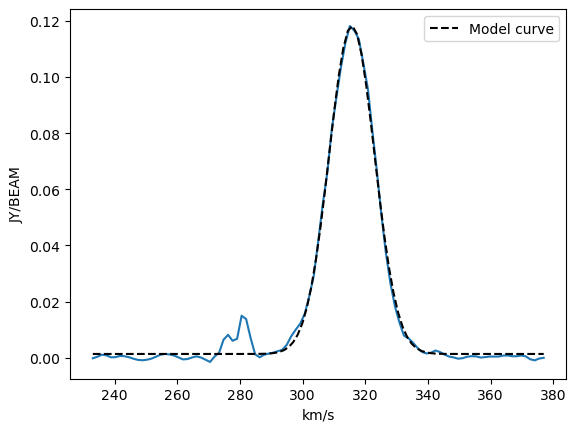

In [12]:
from matplotlib.pyplot import figure, show

newv = np.linspace(np.min(v), np.max(v), 100)
fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(v, profile)
frame.plot(newv, f(newv, *popt), linestyle='--', color='black', label='Model curve')
frame.set_xlabel(hdr['CUNIT3'])
frame.set_ylabel(hdr['BUNIT'])
frame.legend()
show()

In [13]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

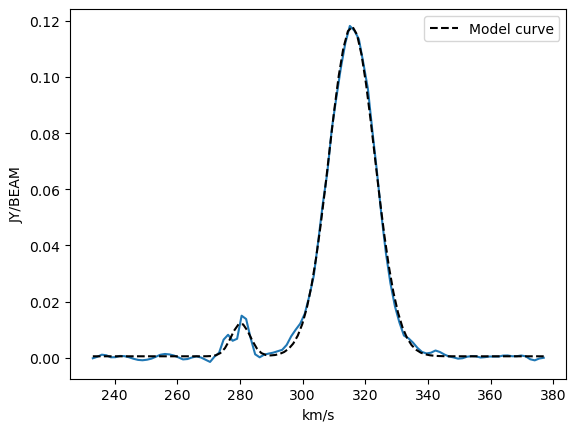

In [14]:
def f2(x, amp1, mu1, sigma1, amp2, mu2, sigma2, zero):
    '''Returns two gaussians instead of just one'''
    g1 = amp1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    g2 = amp2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    return g1 + g2 + zero
amp2 = 0.02
mu2 = 280
sigma2 = 2
popt2, pcov2 = curve_fit(f2, v, profile, p0=(amp0, mu0, sigma0, amp2, mu2, sigma2, zero0))

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(v, profile)
frame.plot(newv, f2(newv, *popt2), linestyle='--', color='black', label='Model curve')
frame.set_xlabel(hdr['CUNIT3'])
frame.set_ylabel(hdr['BUNIT'])
frame.legend()
show()

In [15]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [16]:
from astropy.stats import gaussian_sigma_to_fwhm

# one standard deviation values from the model in the last plot
perr = np.sqrt(np.diag(pcov2))

# Calculating the FWHM of both peaks
(amp, mu, sigma, amp_small, mu_small, sigma_small, zero) = popt2
fwhm = sigma * gaussian_sigma_to_fwhm
fwhm_small = sigma_small * gaussian_sigma_to_fwhm

sigma_err = perr[2]
sigma_small_err = perr[5]
fwhm_err = sigma_err * gaussian_sigma_to_fwhm
fwhm_small_err = sigma_small_err * gaussian_sigma_to_fwhm

print(f"FWHM in main peak = {fwhm} ± {fwhm_err} km/s")
print(f"FWHM in secondary peak = {fwhm_small} ± {fwhm_small_err} km/s")

FWHM in main peak = 17.271770099768563 ± 0.11045768552400778 km/s
FWHM in secondary peak = 7.115082918012689 ± 0.6838312892173288 km/s


In [17]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

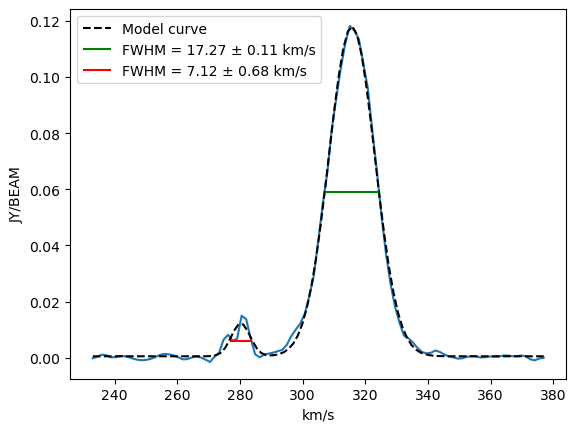

In [18]:
fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(v, profile)
frame.plot(newv, f2(newv, *popt2), linestyle='--', color='black', label='Model curve')
yvalue = (amp + zero) / 2
yvalue_small = (amp_small + zero) / 2
frame.hlines(yvalue, mu-fwhm/2, mu+fwhm/2, color='green', label=f'FWHM = {fwhm:.2f} ± {fwhm_err:.2f} km/s')
frame.hlines(yvalue_small, mu_small-fwhm_small/2, mu_small+fwhm_small/2, color='red', label=f'FWHM = {fwhm_small:.2f} ± {fwhm_small_err:.2f} km/s')
frame.set_xlabel(hdr['CUNIT3'])
frame.set_ylabel(hdr['BUNIT'])
frame.legend()
show()

In [19]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   ![image.png](attachment:2f684ef4-1ed4-4827-b0e4-a6bd194ca61c.png)    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

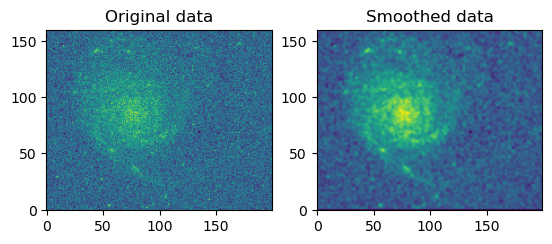

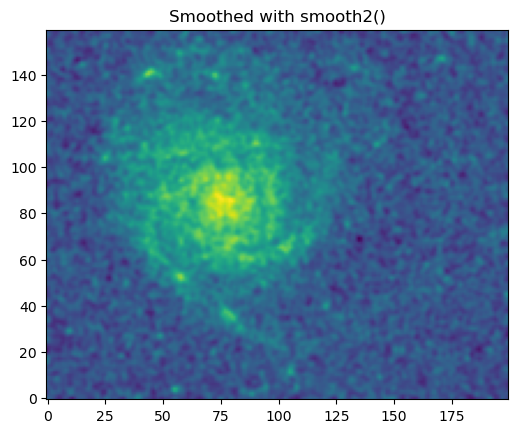

In [20]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import ndimage

hdulist = fits.open('faintgalaxy.fits')
data = hdulist[0].data 

def smooth(M):
    Mc = np.zeros_like(M) # border pixels are ignored in the for loop and are set to zero
    for i in range(1, M.shape[0]-1):
        for j in range(1, M.shape[1]-1):
            Mc[i, j] = np.mean(M[i-1:i+2, j-1:j+2])
    return Mc

data_smooth = smooth(data)

fig = figure()
frame = fig.add_subplot(1, 2, 1)
frame.imshow(data, origin='lower')
frame.set_title('Original data')
frame = fig.add_subplot(1, 2, 2)
frame.imshow(data_smooth, origin='lower')
frame.set_title('Smoothed data')
show()

def smooth2(M):
    Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
    return Mc

data_smooth2 = smooth2(data)
fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.imshow(data_smooth2, origin='lower')
frame.set_title('Smoothed with smooth2()')
show()

In [21]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [22]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 25. Student score: 0.0.  Task Grade = 0.0
